# EXPRESSIVE PUNCTUATION PATTERNS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import string
import re
import datasets
import random

C:\Users\jslui\anaconda3\envs\docana\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pre-Processsing
Loading of The Reddit Dataset and Extraction of 30% of training data.

In [2]:
from datasets import load_dataset

tldr = load_dataset("webis/tldr-17", split = 'train[:30%]') # only 30% of data is used to train 

C:\Users\jslui\anaconda3\envs\docana\lib\site-packages\datasets\table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [3]:
# 3 random examples from the Webis-TLDR-17 TIFU dataset:
def show_random_elements(dataset, num_examples=3):
    picks = random.sample(range(len(dataset)), num_examples)
    for i in picks:
        print(dataset[i])
        print("---")

show_random_elements(tldr)

{'author': 'mynameisthemaster1', 'body': 'Late to the party, but whatever\n\nIn sixth grade, there was an after school dance where only sixth graders could go.  Seeing this as an opportunity to get socially awkward me somewhat popular, and because it was only October, I bought a ticket and went to the dance.\n\nThe Friday came, and the dance started immediately after school.  I hung out with my friends, played the shitty carnival games in the main hall, and talked with my friends.  Everything went smoothly, until I went in the cafeteria.\n\nThe cafeteria is where the actual "dancing" was being held.  There was a DJ there, a group of kids had a dance circle, and I found a group of friends in the cafeteria.  So naturally I went over to them, one kid did the worm, it was funny, blah blah blah.  Then, as a joke, one of my friends started a conga line.  I thought it was funny, and I joined in too.  Just as everything was going well, *I tripped*.  I got back up, and I noticed that my foot hu

## Subreddit Selection
Here we find the top 10 subreddits in the data and we sort them in descending order

In [4]:
subreddit_count = {}

for subreddit in tldr['subreddit']:
    subreddit_count[subreddit] = subreddit_count.get(subreddit, 0) + 1

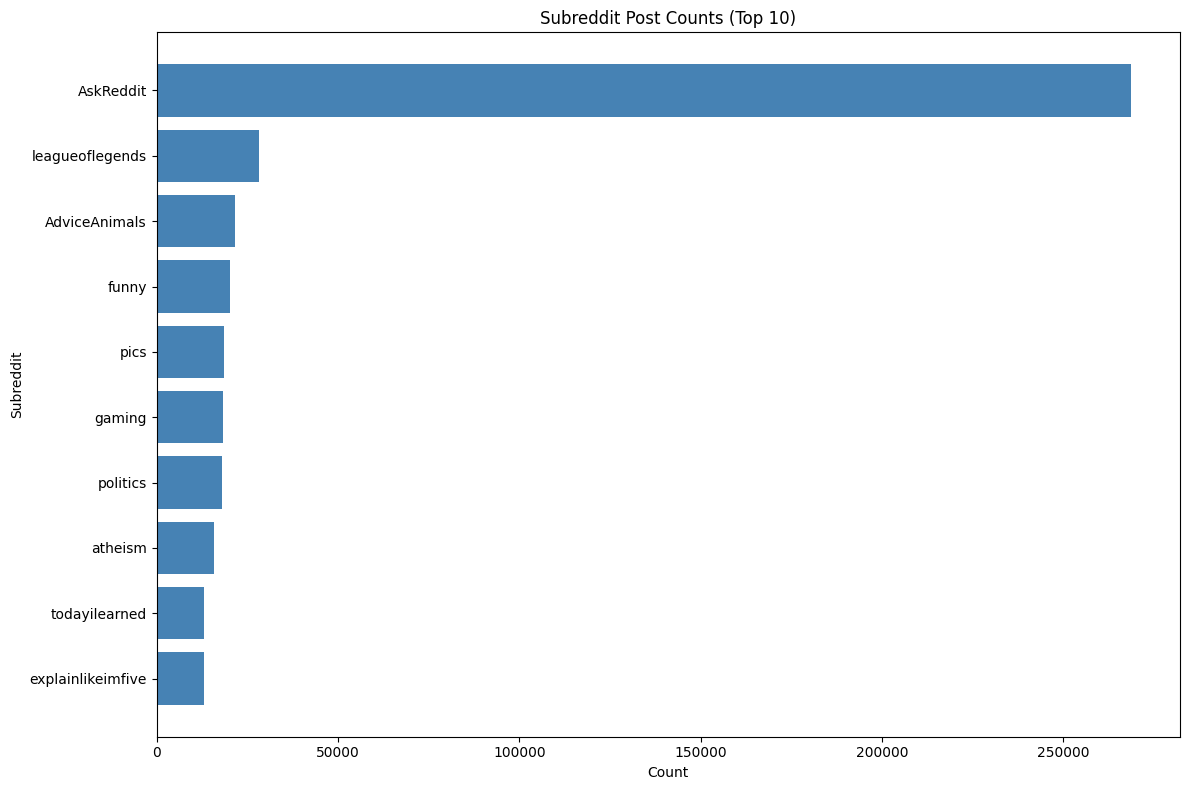

In [5]:
# Sort by count descending and take top 10
subs_10 = sorted(subreddit_count.items(), key=lambda x: x[1], reverse=True)[:10]
subreddits, counts = zip(*subs_10)

plt.figure(figsize=(12, 8))
plt.barh(subreddits, counts, color='steelblue')
plt.xlabel('Count')
plt.ylabel('Subreddit')
plt.title('Subreddit Post Counts (Top 10)')
plt.gca().invert_yaxis()
plt.savefig("../figures/EDA_Top_10_Subreddits.png")
plt.tight_layout()
plt.show()

In [6]:
# subreddits is a tuple of names from the chart above, e.g. ('AskReddit', 'tifu', ...)
top_10_subs = list(subreddits)

# filter dataset to only posts from those top 10 subreddits
dfilt = tldr.filter(lambda x: x['subreddit'] in top_10_subs)
print(top_10_subs)

['AskReddit', 'leagueoflegends', 'AdviceAnimals', 'funny', 'pics', 'gaming', 'politics', 'atheism', 'todayilearned', 'explainlikeimfive']


## Feature Engineering
### Tokenization

In [7]:
def get_tokens(text):
    return nltk.word_tokenize(text)

def get_sentences(text):
    return nltk.sent_tokenize(text)

### Chosen Punctuation Expressions
Modern vernacular includes certain chains of punctuations that can be used to express different ranges of emotions
- ...  =>  pause or unfinished though
- ???? => extreme confusion
- !!!!!=> intense feelings of happiness/ anger
- ?!?! => interrobang
- !?!? => interrobang

In addition, we have chosen Periods, Exclamation points and Question Marks for our analysis.

In [8]:
EXPRESSIVE_PATTERNS = {
    "ELLIPSIS": r"\.{3,}",       # ..., ...., .....
    "MULTI_QUEST": r"\?{2,}",        # ??, ???, ?????
    "MULTI_EXCL": r"!{2,}",         # !!, !!!, !!!!!!
    "QUEST-EXCL": r"(?:\?!){2,}",       # ?!?!, ?!?!?! ...
    "EXCL-QUEST": r"(?:!\?){2,}",       # !?!?, !?!?!? ...
}
BASE_PUNCT = {".", "!", "?"}  # period, exclamation, question mark

### Punctuation Count
We use 1500 as max number of posts to reduce the runtime.\
Tokenization splits text into words and punctuation marks, then filters out only punctuation tokens for analysis

In [9]:
from collections import Counter

max_posts=1500
def get_punctuation_counts(subreddit):
    punctuation = []
    expressive = Counter()

    count = 0
    for row in dfilt:
        if row['subreddit'] != subreddit:
            continue

        text = str(row['content'])

        # count expressive punctuation
        for name, pattern in EXPRESSIVE_PATTERNS.items():
            expressive[name] += len(re.findall(pattern, text))

        #Tokenization 
        tokens = get_tokens(text)
        punctuation.extend(t for t in tokens if t in BASE_PUNCT)

        count += 1
        if count >= max_posts:
            break

    return Counter(punctuation) + expressive

### Average sentence length
$$=\frac{Total\ no.\ of\ words}{Total\ no.\ of\ sentences}$$

In [10]:
def get_avg_sentence_length(subreddit):
    total_words = 0
    total_sentences = 0
    count = 0
    for row in dfilt:
        if row['subreddit'] != subreddit:
            continue
        text = str(row['content'])
        sentences = get_sentences(text)
        for sent in sentences:
            sent_tokens = get_tokens(sent)
            words = [t for t in sent_tokens if t not in string.punctuation]
            total_words += len(words)
            total_sentences += 1
        count += 1
        if count >= max_posts:
            break
    return (total_words / total_sentences) if total_sentences > 0 else 0.0


### Average words between punctuation
$$=\frac{Total\ words\ between\ punctuation\ marks}{Total\ no.\ of\ intervals}$$

In [11]:
def get_avg_words_between_punct(subreddit):
    total_intervals = 0
    total_words = 0
    count = 0
    for row in dfilt:
        if row['subreddit'] != subreddit:
            continue
        text = str(row['content'])
        tokens = get_tokens(text)
        words_since_punct = 0
        for token in tokens:
            if token in BASE_PUNCT or any(re.fullmatch(p, token) for p in EXPRESSIVE_PATTERNS.values()):
                total_intervals += 1
                total_words += words_since_punct
                words_since_punct = 0
            else:
                words_since_punct += 1
        count += 1
        if count >= max_posts:
            break
    return (total_words / total_intervals) if total_intervals > 0 else 0.0

### Printing & Saving Results

In [12]:
# Loop through subreddits and print results
results = []
for sub in top_10_subs:
    punct_counts = get_punctuation_counts(sub)
    avg_sent_len = get_avg_sentence_length(sub)
    avg_words_punct = get_avg_words_between_punct(sub)
    results.append({
        "subreddit": sub,
        "punctuation_counts": punct_counts,
        "avg_sentence_length": avg_sent_len,
        "avg_words_between_punct": avg_words_punct
    })
    print(f"\n\nr/{sub}")
    print("-" * 150)
    print("punctuation_counts:", punct_counts)
    print("avg_sentence_length:",avg_sent_len)
    print("avg_words_between_punct:", avg_words_punct)



r/AskReddit
------------------------------------------------------------------------------------------------------------------------------------------------------
punctuation_counts: Counter({'.': 17313, '?': 733, 'ELLIPSIS': 633, '!': 625, 'MULTI_EXCL': 57, 'MULTI_QUEST': 17, 'QUEST-EXCL': 4, 'EXCL-QUEST': 2})
avg_sentence_length: 17.8302188148858
avg_words_between_punct: 18.23300870285951


r/leagueoflegends
------------------------------------------------------------------------------------------------------------------------------------------------------
punctuation_counts: Counter({'.': 11273, '?': 661, 'ELLIPSIS': 281, '!': 223, 'MULTI_EXCL': 12, 'MULTI_QUEST': 6})
avg_sentence_length: 20.07037156184655
avg_words_between_punct: 20.958353433027817


r/AdviceAnimals
------------------------------------------------------------------------------------------------------------------------------------------------------
punctuation_counts: Counter({'.': 12905, '?': 823, 'ELLIPSIS': 502

### Visualization
For conversion of counts to percentages, $e^{-9}$ is added to prevent division by zero i.e when a subreddit has no punctuation.

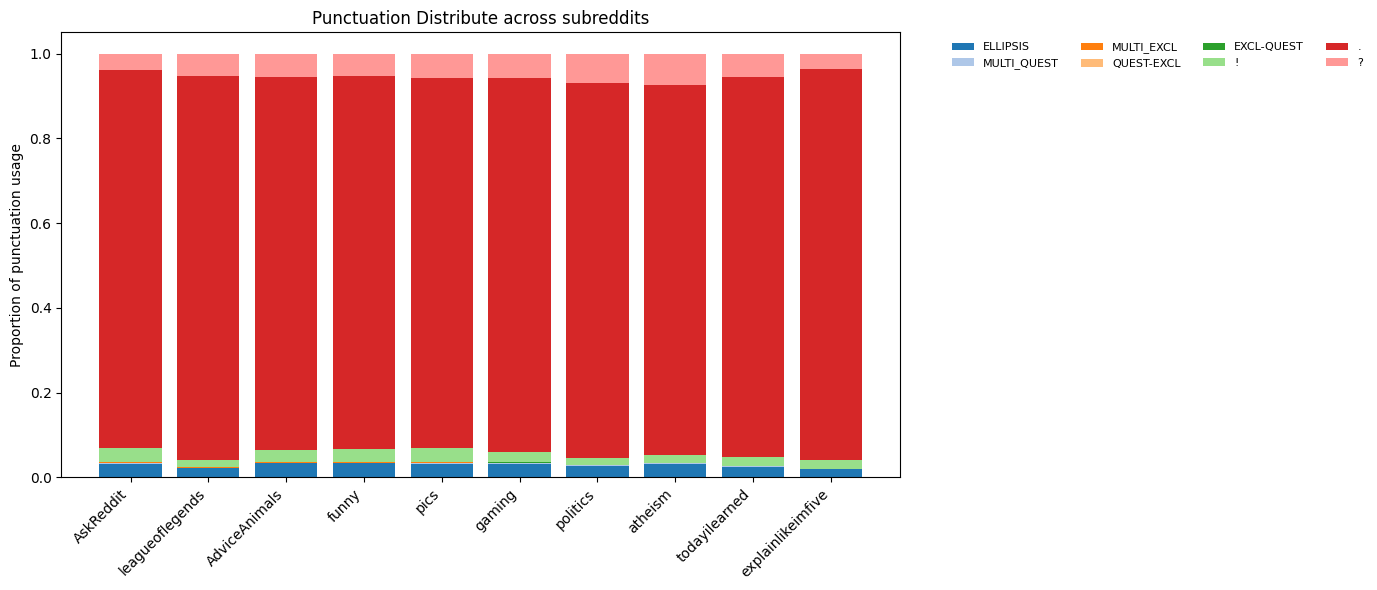

In [13]:
features = list(EXPRESSIVE_PATTERNS.keys()) + list(BASE_PUNCT)#use normal punctuations and expressive patterns
labels = top_10_subs
matrix = []
punct_lookup = {r["subreddit"]: r["punctuation_counts"] for r in results}

for sub in labels:
    counts = punct_lookup[sub]
    matrix.append([counts.get(f, 0) for f in features])

matrix = np.array(matrix)

row_sums = matrix.sum(axis=1, keepdims=True)
#converts counts to percentages
norm_matrix = matrix / (row_sums + 1e-9)

#Includes contrasting colours
colors = (
    list(plt.cm.tab20.colors) +
    list(plt.cm.tab20b.colors) +
    list(plt.cm.tab20c.colors)
)

#according to the number of features
colors = colors[:len(features)]

plt.figure(figsize=(14,6))

bottom = np.zeros(len(labels))

for i, feat in enumerate(features):
    plt.bar(
        labels,
        norm_matrix[:, i],
        bottom=bottom,
        color=colors[i],
        label=feat
    )
    bottom += norm_matrix[:, i]

plt.xticks(rotation=45, ha='right')
plt.ylabel("Proportion of punctuation usage")
plt.title("Punctuation Distribute across subreddits")

plt.legend(
    ncol=4,
    fontsize=8,
    bbox_to_anchor=(1.05, 1),
    frameon=False
)
plt.savefig("../figures/EDA_Punctuation_Distribution.png")
plt.tight_layout()
plt.show()

## Classification
A classifier is used to predict the subreddit based on punctuation.

### Frequency per 1000 words
We calculate the punctuation frequency per 1000 words for 1500 posts in groups of 20 for each of the 10 subreddits we chose. Then turn that into a csv file.

In [14]:
# SETTINGS
MAX_POSTS_PER_SUB = 1500
GROUP_SIZE = 20

PUNCT_LIST = list(BASE_PUNCT)

# FEATURE EXTRACTION
def extract_punct_features(text):

    #Tokenization
    tokens = get_tokens(text)

    #Word Counting
    words = [t for t in tokens if t not in string.punctuation]
    n_words = len(words)

    #Handle empty text
    if n_words == 0:
        feats = {p: 0.0 for p in PUNCT_LIST}
        for k in EXPRESSIVE_PATTERNS:
            feats[k] = 0.0
        return feats

    #Punctuation counter
    counts = Counter(t for t in tokens if t in string.punctuation)

    #Normalization of punctuation per word
    feats = {
        p: (counts.get(p, 0) / n_words) * 1000
        for p in PUNCT_LIST
    }

    # expressive punctuation frequencies per 100 words
    for name, pattern in EXPRESSIVE_PATTERNS.items():
        feats[name] = (
            len(re.findall(pattern, text)) / n_words
        ) * 1000

    return feats

# BUILD CSV DATASET
posts_by_sub = {sub: [] for sub in top_10_subs}
still_needed = set(top_10_subs)

for row in dfilt:
    sub = row["subreddit"]
    if sub in still_needed:
        posts_by_sub[sub].append(str(row["content"]))
        if len(posts_by_sub[sub]) >= MAX_POSTS_PER_SUB:
            still_needed.discard(sub)
    if not still_needed:
        break
        
rows = []

for sub in top_10_subs:

    subreddit_posts = posts_by_sub[sub]
    
    # create groups of 20 posts
    for i in range(0, len(subreddit_posts), GROUP_SIZE):

        chunk = subreddit_posts[i:i + GROUP_SIZE]

        if len(chunk) < GROUP_SIZE:
            continue

        combined_text = " ".join(chunk)

        feats = extract_punct_features(combined_text)

        feats["subreddit"] = sub
        feats["group_id"] = i // GROUP_SIZE

        rows.append(feats)

# dataframe
punct_df = pd.DataFrame(rows)

# subreddit first
cols = (
    ["subreddit", "group_id"] +
    [c for c in punct_df.columns
     if c not in ["subreddit", "group_id"]]
)

punct_df = punct_df[cols]

# save
punct_df.to_csv("../figures/punctuation_features.csv", index=False)

print("Rows:", len(punct_df))
print("Rows per subreddit:", MAX_POSTS_PER_SUB // GROUP_SIZE)
print(punct_df.head())

Rows: 750
Rows per subreddit: 75
   subreddit  group_id         !          .         ?  ELLIPSIS  MULTI_QUEST  \
0  AskReddit         0  1.843129  47.921360  2.457506  1.228753     0.000000   
1  AskReddit         1  3.243945  59.472318  3.027682  2.162630     0.000000   
2  AskReddit         2  0.000000  53.722903  9.425071  2.199183     1.885014   
3  AskReddit         3  4.800000  58.560000  3.840000  1.920000     0.000000   
4  AskReddit         4  0.885152  52.666519  1.991591  1.327727     0.000000   

   MULTI_EXCL  QUEST-EXCL  EXCL-QUEST  
0    0.204792         0.0         0.0  
1    0.216263         0.0         0.0  
2    0.000000         0.0         0.0  
3    0.640000         0.0         0.0  
4    0.000000         0.0         0.0  


### Cosine Similarity of the Subreddits

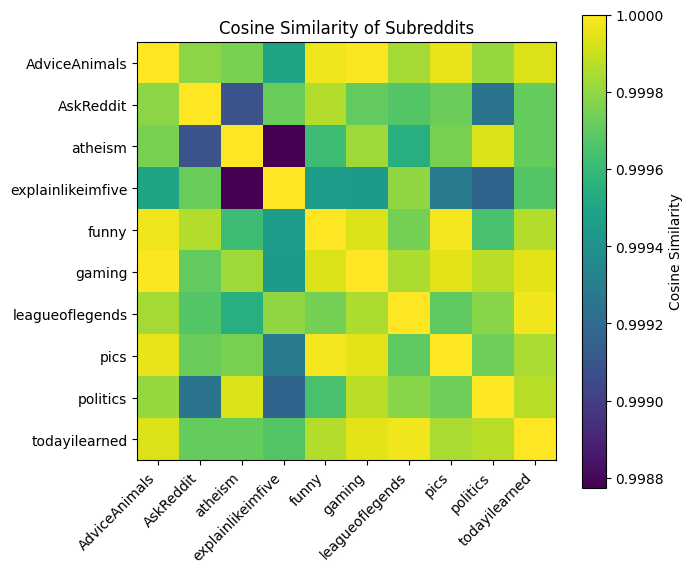

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# Average punctuation profile for each subreddit
group_means = (
    punct_df
    .drop(columns=["group_id"])
    .groupby("subreddit")
    .mean()
)

# Cosine similarity matrix
cos_sim = cosine_similarity(group_means)

# Plot
plt.figure(figsize=(7, 6))
plt.imshow(cos_sim, cmap="viridis")
plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(group_means.index)),
           group_means.index,
           rotation=45,
           ha="right")
plt.yticks(range(len(group_means.index)),
           group_means.index)

plt.title("Cosine Similarity of Subreddits")
plt.tight_layout()
plt.savefig("../figures/EDA_CosineSimilarity.png")
plt.show()

### Classifiers and Scores
We use 2 kinds of classifier to determine if linear separation plays a role.\
Each model studies to find correlation between the punctuation and the subreddit.
1. **Random Forest Classifier**: Here, the guesses of the 200 trees(n_estimator) is then averaged during prediction. Random Forest Classifier learns the rules and takes a majority vote from the different trees.
2. **LinearSVC**: LinearSVC assumes that subreddits can be separated by relatively simple linear relationships between punctuation features.

In [16]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
def evaluate_models(X, y, feature_set_name):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    print(f"\n==================== {feature_set_name} ====================")

    # ---------------- RANDOM FOREST ----------------
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    rf.fit(X_train, y_train)

    rf_pred = rf.predict(X_test)

    rf_acc = accuracy_score(y_test, rf_pred)

    print("\n----- Random Forest -----")
    print(f"Accuracy: {rf_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, rf_pred))


    # ---------------- LINEAR SVC ----------------
    svm = LinearSVC(
        random_state=42,
        max_iter=5000
    )
    svm.fit(X_train, y_train)

    svm_pred = svm.predict(X_test)

    svm_acc = accuracy_score(y_test, svm_pred)

    print("\n----- LinearSVC -----")
    print(f"Accuracy: {svm_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, svm_pred))


    # return summary (optional for later comparison tables)
    return {
    "Feature Set": feature_set_name,
    "RF Accuracy": rf_acc,
    "LinearSVC Accuracy": svm_acc,
    "rf_model": rf,
    "rf_pred": rf_pred,
    "svm_model": svm,
    "svm_pred": svm_pred,
    "X_test": X_test,
    "y_test": y_test,
}

In [17]:
y = punct_df["subreddit"]

EXPRESSIVE_FEATURES = list(EXPRESSIVE_PATTERNS.keys())+ list(BASE_PUNCT)
X = punct_df.drop(columns=["subreddit", "group_id"])

cl_res = evaluate_models(X, y, "Expressive Features")


==================== Expressive Features ====================

----- Random Forest -----
Accuracy: 0.1911

Classification Report:
                   precision    recall  f1-score   support

    AdviceAnimals       0.14      0.14      0.14        22
        AskReddit       0.31      0.41      0.35        22
          atheism       0.22      0.17      0.20        23
explainlikeimfive       0.21      0.30      0.25        23
            funny       0.06      0.04      0.05        23
           gaming       0.18      0.23      0.20        22
  leagueoflegends       0.22      0.22      0.22        23
             pics       0.09      0.09      0.09        22
         politics       0.29      0.27      0.28        22
    todayilearned       0.09      0.04      0.06        23

         accuracy                           0.19       225
        macro avg       0.18      0.19      0.18       225
     weighted avg       0.18      0.19      0.18       225


----- LinearSVC -----
Accuracy: 0.2267


### Conclusion:
As LinearSVC has outperformed Random Forest, it means that the punctuations we selected are more linearly seperable.LinearSVC finds a single hyperplane per class, which is more robust when features are weak/noisy

### Visualization
We only consider the results from Random Forest Classification of the all punctuation and expressions set for visualization.
#### 1. Precision-Recall:

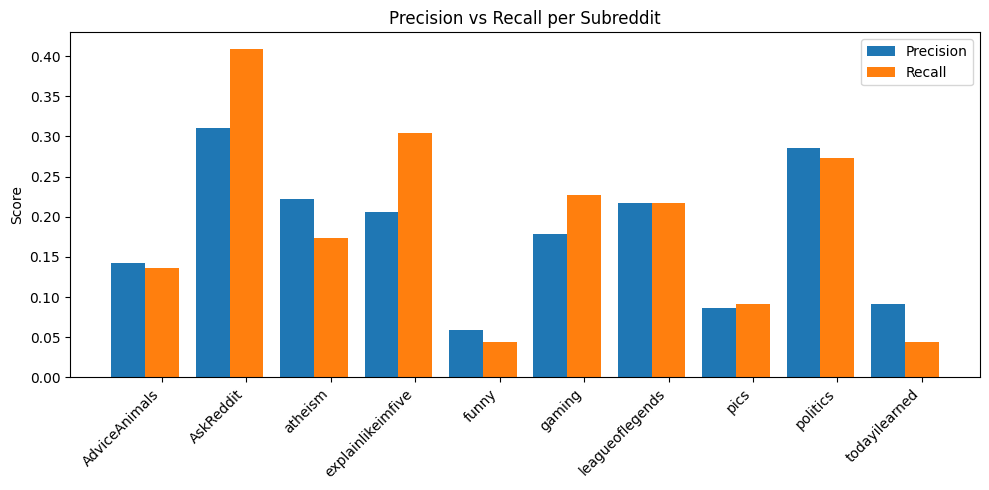

In [18]:
rf = cl_res["rf_model"]
rf_pred = cl_res["rf_pred"]
y_test = cl_res["y_test"]

labels = sorted(set(y))

# REMOVE labels=labels and target_names=labels
report = classification_report(y_test, rf_pred, output_dict=True, zero_division=0)

classes = list(report.keys())[:-3]  # ignore accuracy, macro avg, weighted avg

precision = [report[c]['precision'] for c in classes]
recall = [report[c]['recall'] for c in classes]

x = range(len(classes))

plt.figure(figsize=(10,5))
plt.bar([i-0.2 for i in x], precision, width=0.4, label="Precision")
plt.bar([i+0.2 for i in x], recall, width=0.4, label="Recall")

plt.xticks([i+0.2 for i in x], classes, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Precision vs Recall per Subreddit")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/EDA_Precision_Recall.png")
plt.show()

High precision and recall (AskReddit, explainlikeimfive, politics) indicate consistent punctuation patterns.
whereas for low precision and recall(funny, pics, todayilearned) indicate no strong distinguishing feature.

#### 2. Importance Factor of Punctuations

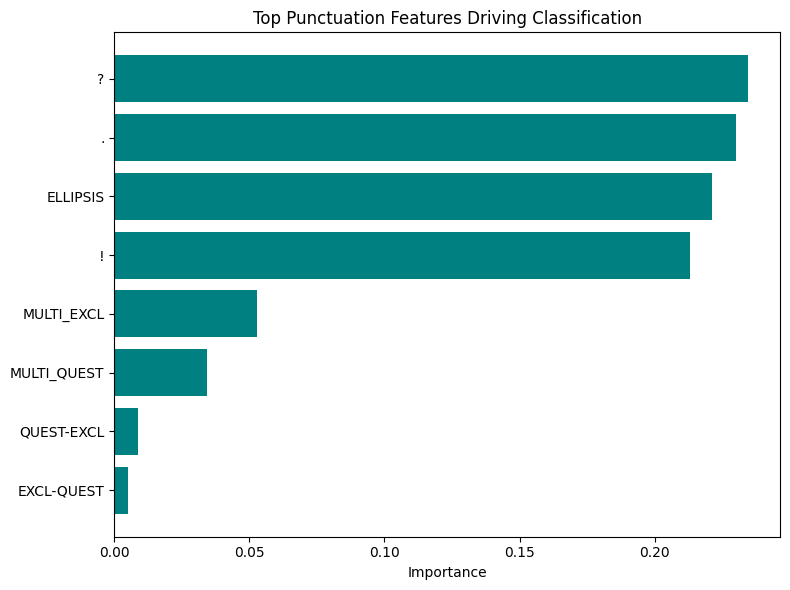

In [19]:
importances = rf.feature_importances_
# remove group_id 
mask = X.columns != "group_id"
features = X.columns[mask]
importances = importances[mask]


idx = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(features[idx], importances[idx], color="teal")

plt.title("Top Punctuation Features Driving Classification")
plt.xlabel("Importance")

plt.tight_layout()
plt.savefig("../figures/EDA_Top_Punct_Features.png")
plt.show()